In [1]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
# GANTI SESUAI DRIVE KAMU
EXTERNAL_DIR = "E:\DATASET\TomatoDataset"

MODEL_DIR = "E:\DATASET\MODEL"

CLASS_NAMES = ["Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___healthy",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus"]
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [3]:
external_ds = tf.keras.utils.image_dataset_from_directory(
    EXTERNAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
    class_names=CLASS_NAMES
).prefetch(tf.data.AUTOTUNE)

print("Dataset luar loaded.")


Found 1609 files belonging to 10 classes.
Dataset luar loaded.


In [4]:
model_configs = {
    "MobileNetV2_FE": "mobilenetv2_fixedfeature.keras",
    "MobileNetV2_FT10": "mobilenetv2_ft10.keras",
    "MobileNetV2_FT20": "mobilenetv2_ft20.keras",
    "MobileNetV2_FT30": "mobilenetv2_ft30.keras",

    "EfficientNetB0_FE": "efficientnetb0_fixedfeature.keras",
    "EfficientNetB0_FT10": "efficientnetb0_ft10.keras",
    "EfficientNetB0_FT20": "efficientnetb0_ft20.keras",
    "EfficientNetB0_FT30": "efficientnetb0_ft30.keras",
}

In [5]:
def evaluate_model(model, dataset):
    y_true, y_pred = [], []

    for x, y in dataset:
        preds = model.predict(x, verbose=0)
        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro Recall": recall_score(y_true, y_pred, average="macro"),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

    return metrics

In [6]:
results = []
conf_matrices = {}

for model_name, file_name in model_configs.items():
    print(f"\nEvaluating {model_name} ...")

    model_path = os.path.join(MODEL_DIR, file_name)
    model = tf.keras.models.load_model(model_path, compile=False)

    metrics = evaluate_model(model, external_ds)

    results.append({
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "Macro Precision": metrics["Macro Precision"],
        "Macro Recall": metrics["Macro Recall"],
        "Macro F1": metrics["Macro F1"]
    })

    conf_matrices[model_name] = metrics["Confusion Matrix"]

results_df = pd.DataFrame(results)
display(results_df)



Evaluating MobileNetV2_FE ...

Evaluating MobileNetV2_FT10 ...

Evaluating MobileNetV2_FT20 ...

Evaluating MobileNetV2_FT30 ...

Evaluating EfficientNetB0_FE ...

Evaluating EfficientNetB0_FT10 ...

Evaluating EfficientNetB0_FT20 ...

Evaluating EfficientNetB0_FT30 ...


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,MobileNetV2_FE,0.321939,0.282926,0.298435,0.278233
1,MobileNetV2_FT10,0.310752,0.250580,0.308939,0.262938
2,MobileNetV2_FT20,0.323804,0.281172,0.305661,0.278844
3,MobileNetV2_FT30,0.330019,0.290549,0.302746,0.282071
4,EfficientNetB0_FE,0.279055,0.253692,0.292444,0.258079
5,EfficientNetB0_FT10,0.295836,0.278671,0.299441,0.274573
6,EfficientNetB0_FT20,0.289621,0.251916,0.295352,0.262783
7,EfficientNetB0_FT30,0.283406,0.253729,0.293822,0.259068


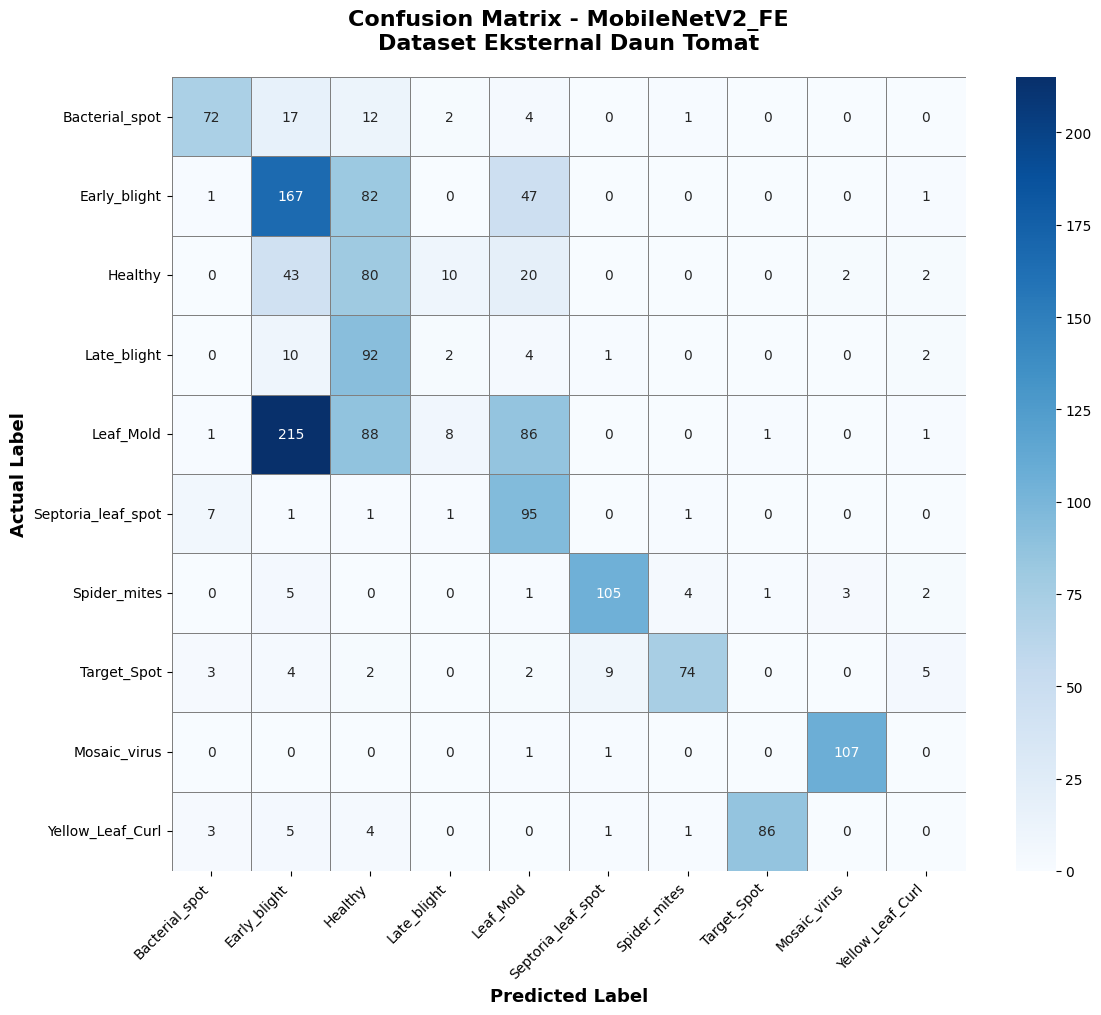

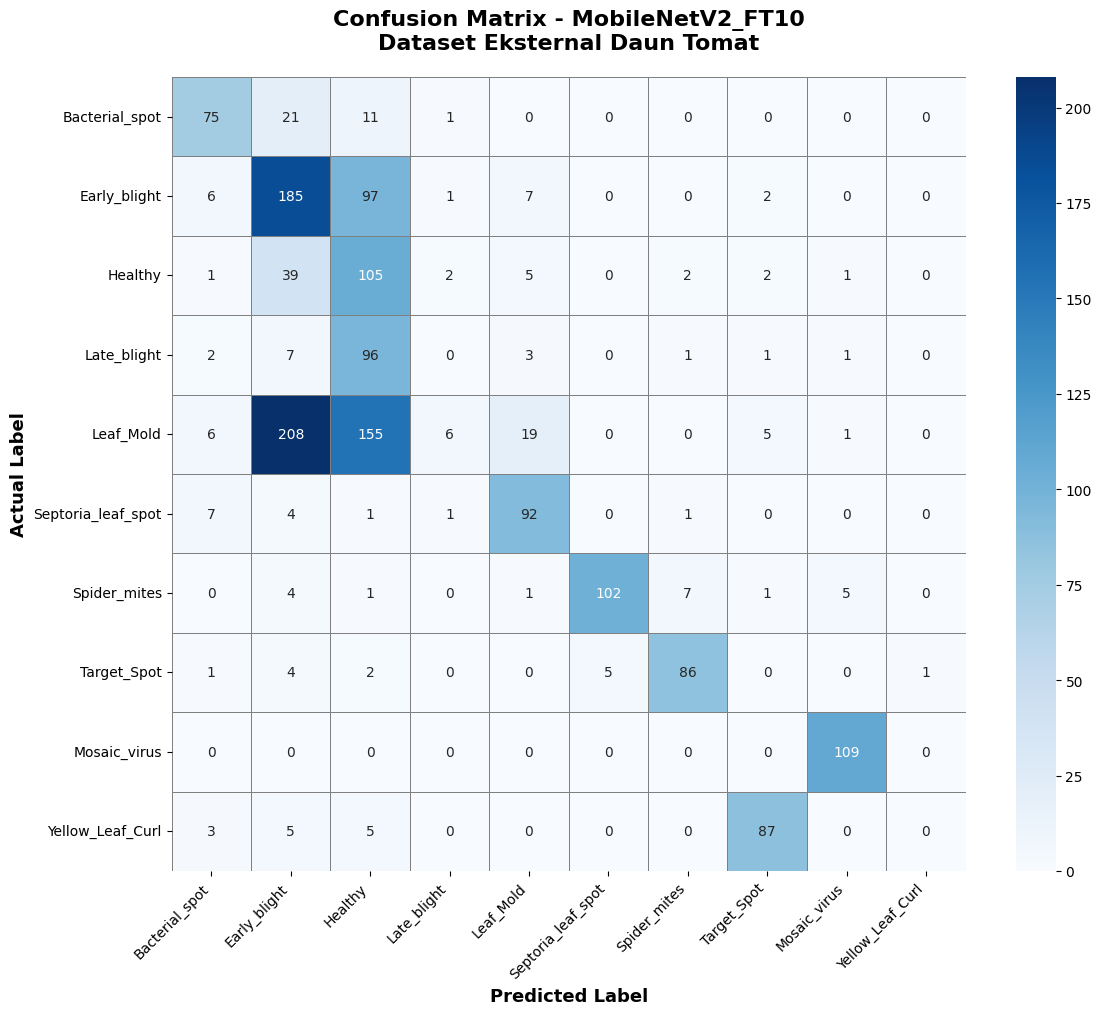

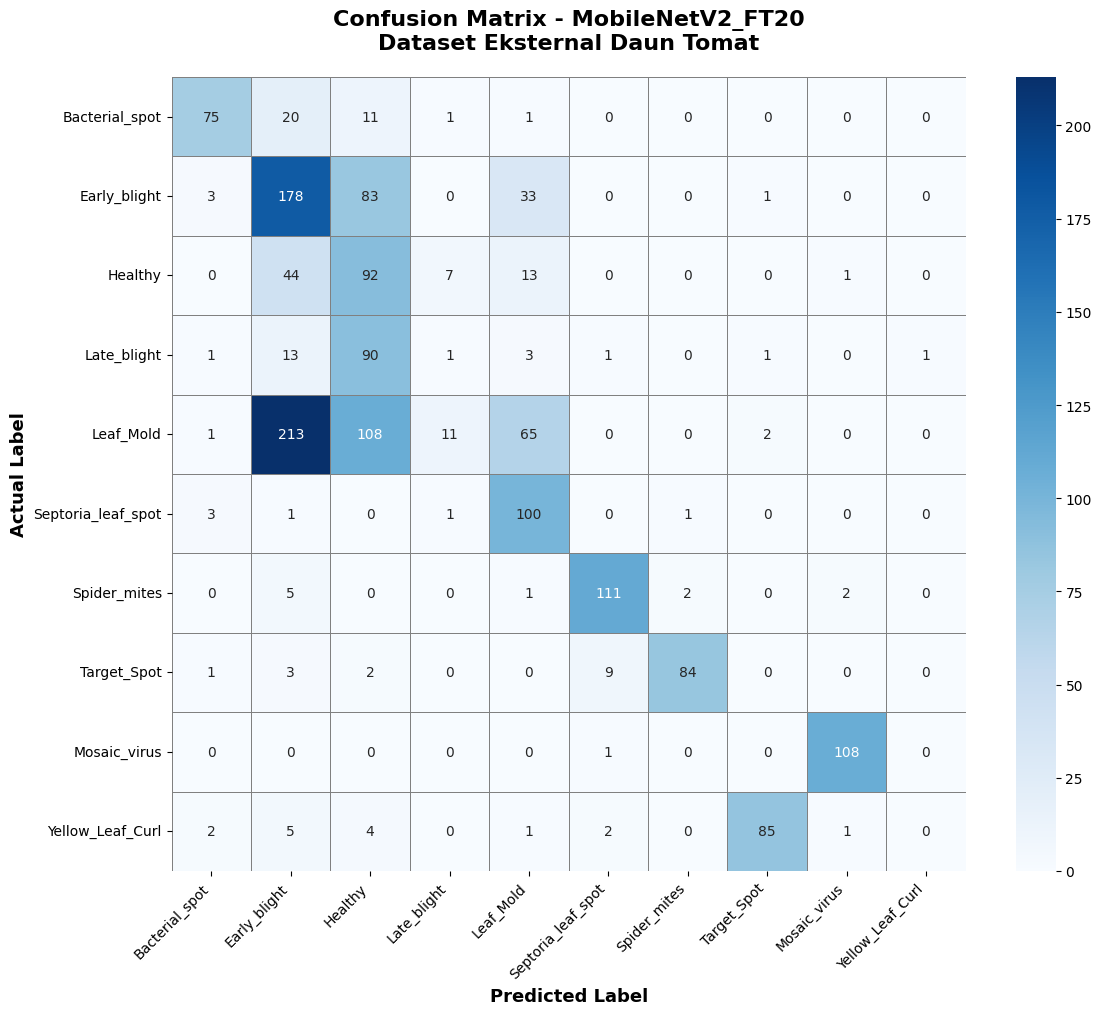

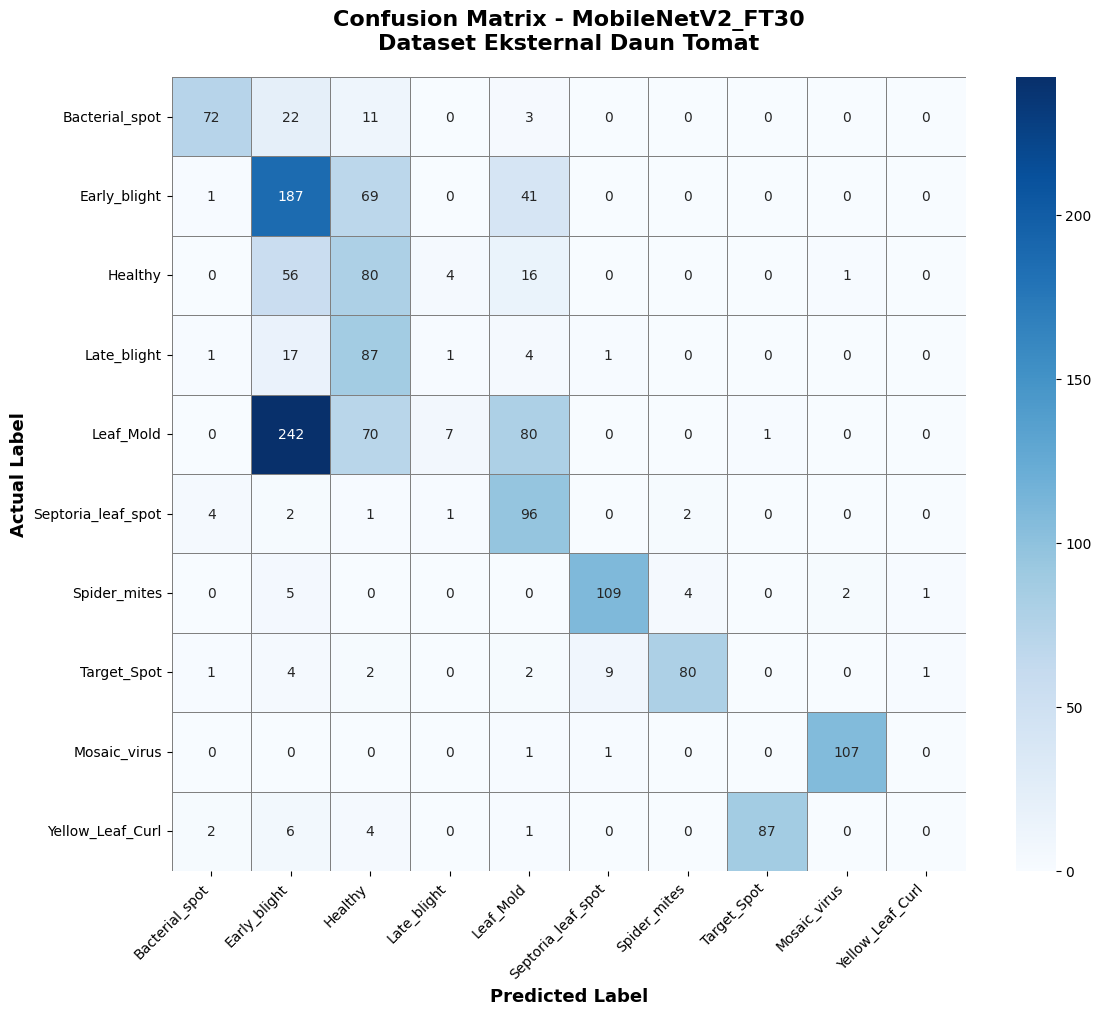

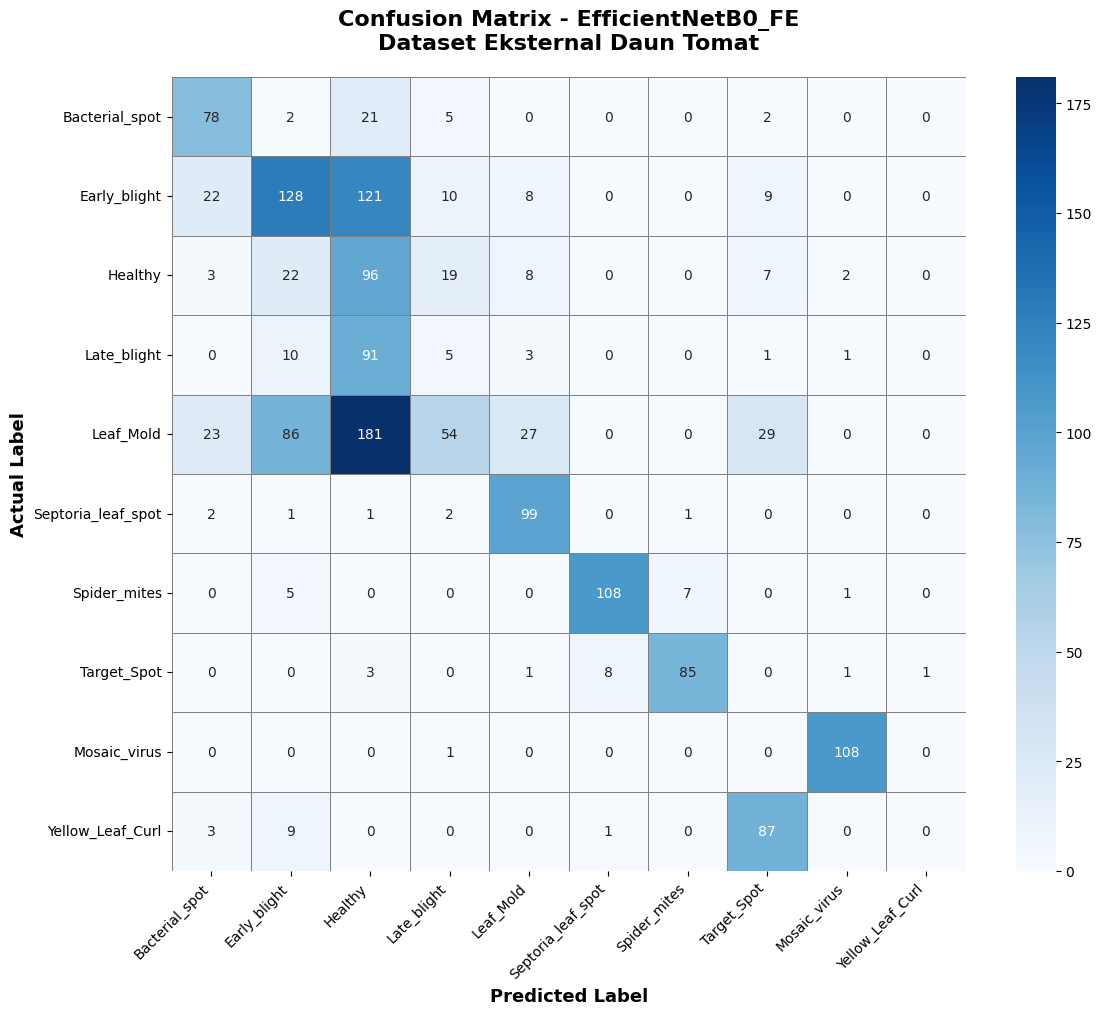

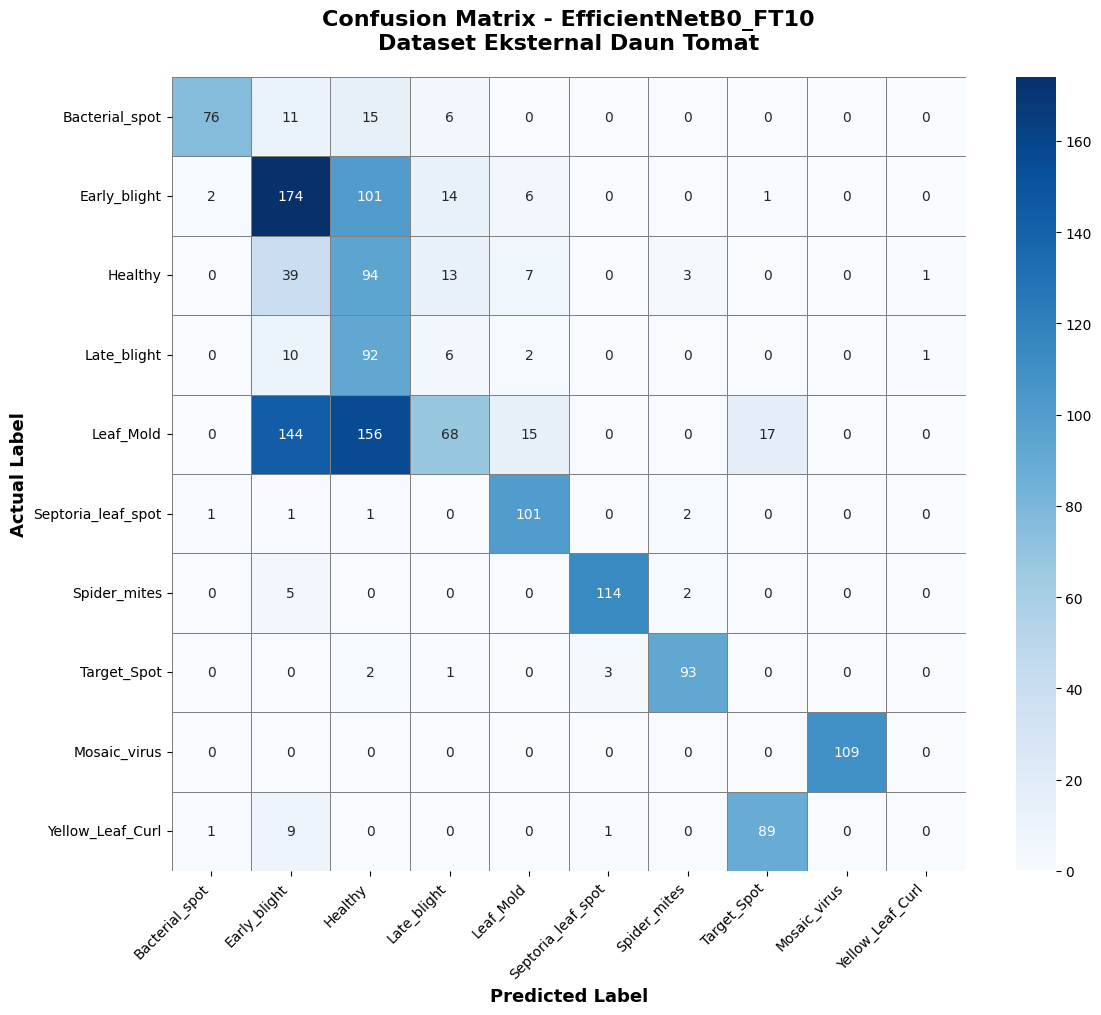

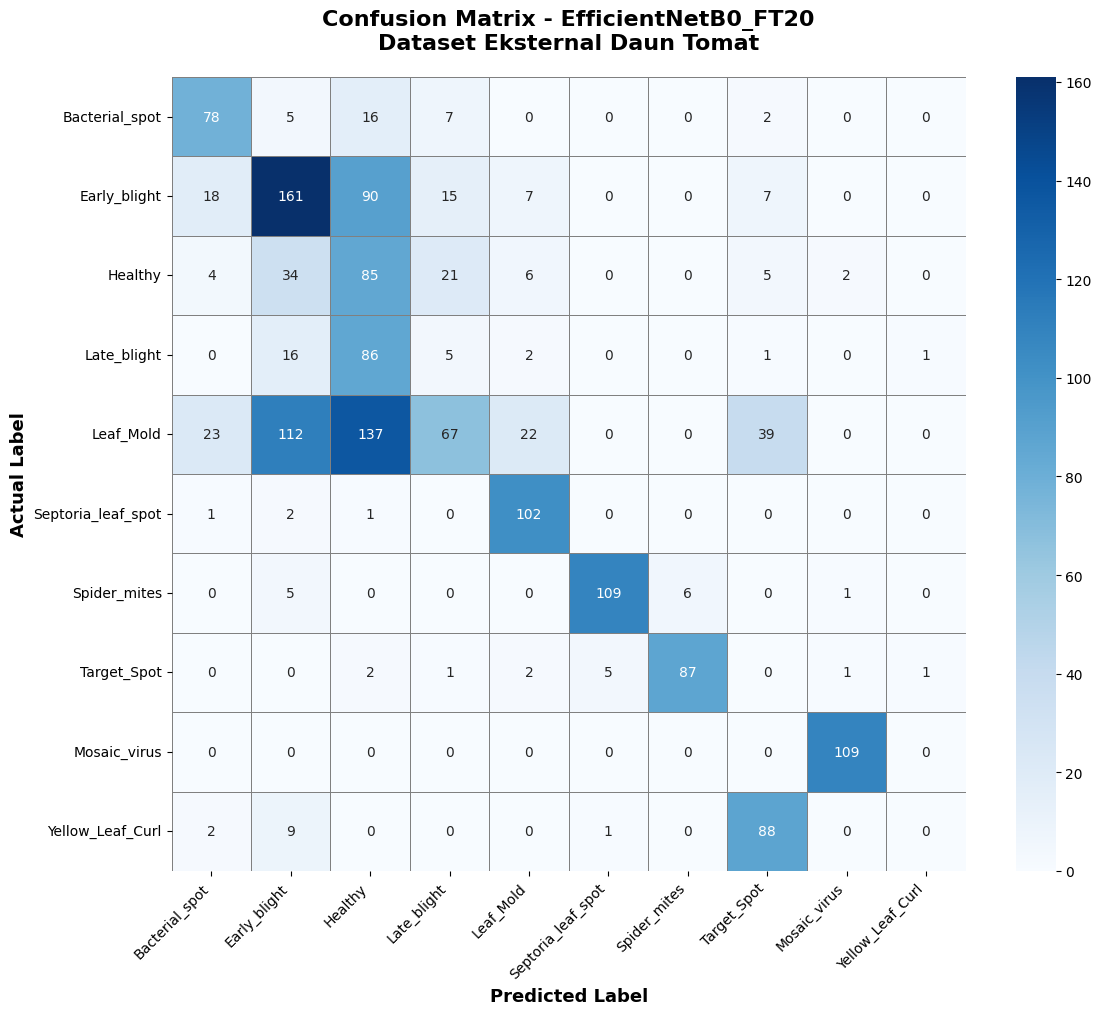

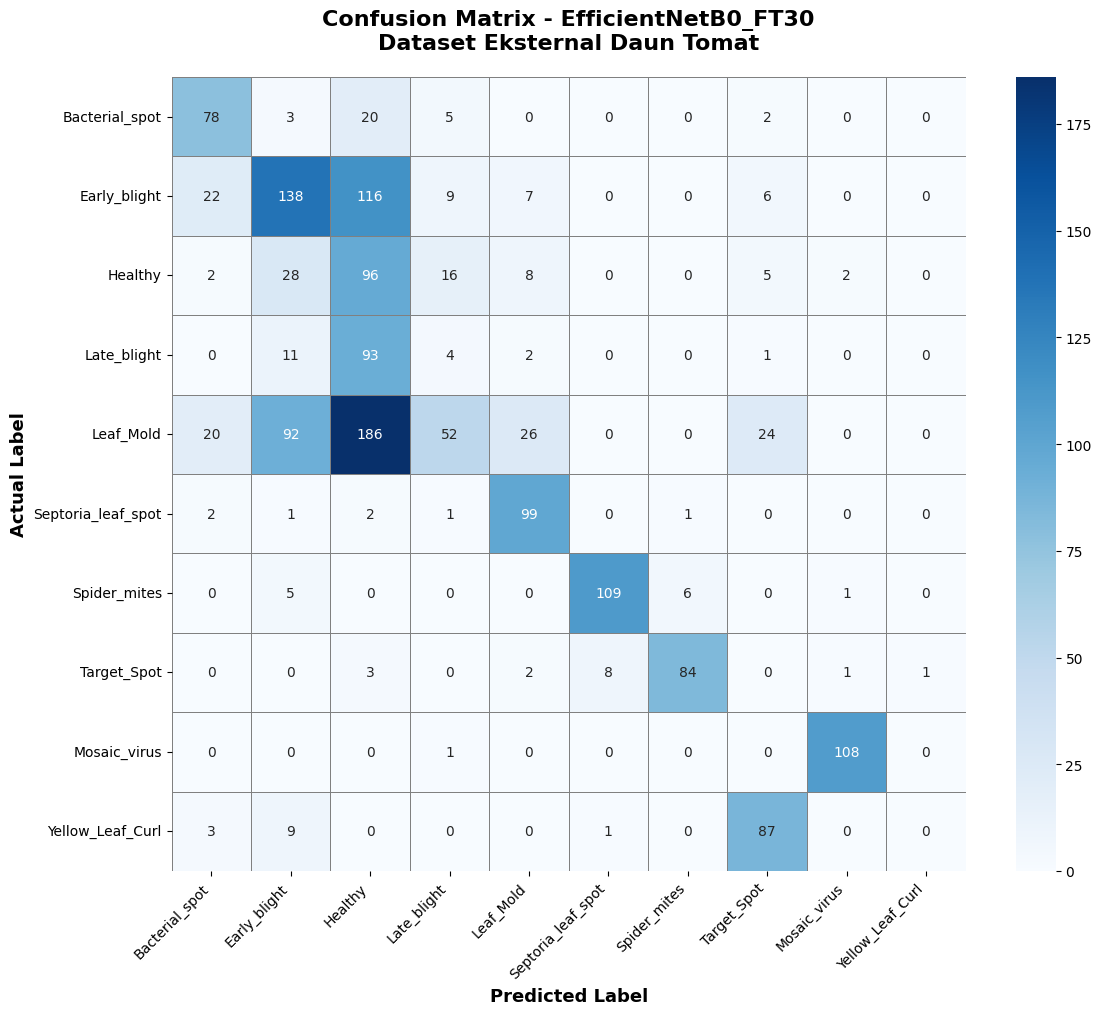

In [7]:
# =========================================
# NAMA KELAS (10 KELAS PENYAKIT TOMAT)
# =========================================
CLASS_NAMES = [
    "Bacterial_spot",
    "Early_blight",
    "Healthy",
    "Late_blight",
    "Leaf_Mold",
    "Septoria_leaf_spot",
    "Spider_mites",
    "Target_Spot",
    "Mosaic_virus",
    "Yellow_Leaf_Curl"
]

# =========================================
# FUNGSI CONFUSION MATRIX RAPI
# =========================================
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor='gray',
        square=True,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={"size":10}
    )

    plt.title(
        title,
        fontsize=16,
        fontweight='bold',
        pad=20
    )

    plt.xlabel(
        "Predicted Label",
        fontsize=13,
        fontweight='bold'
    )

    plt.ylabel(
        "Actual Label",
        fontsize=13,
        fontweight='bold'
    )

    plt.xticks(
        rotation=45,
        ha='right',
        fontsize=10
    )

    plt.yticks(
        rotation=0,
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

# =========================================
# TAMPILKAN SEMUA CONFUSION MATRIX
# =========================================
for model_name, cm in conf_matrices.items():

    plot_confusion_matrix(
        cm,
        f"Confusion Matrix - {model_name}\nDataset Eksternal Daun Tomat"
    )

In [8]:
mobilenet_df = results_df[
    results_df["Model"].str.contains("MobileNetV2")
]

mobilenet_avg_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Average Value": [
        mobilenet_df["Accuracy"].mean(),
        mobilenet_df["Macro Precision"].mean(),
        mobilenet_df["Macro Recall"].mean(),
        mobilenet_df["Macro F1"].mean()
    ]
})

display(mobilenet_avg_df)


,Metric,Average Value
0,Accuracy,0.321628
1,Macro Precision,0.276307
2,Macro Recall,0.303945
3,Macro F1,0.275522


In [9]:
efficientnet_df = results_df[
    results_df["Model"].str.contains("EfficientNetB0")
]

efficientnet_avg_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Average Value": [
        efficientnet_df["Accuracy"].mean(),
        efficientnet_df["Macro Precision"].mean(),
        efficientnet_df["Macro Recall"].mean(),
        efficientnet_df["Macro F1"].mean()
    ]
})

display(efficientnet_avg_df)


,Metric,Average Value
0,Accuracy,0.286979
1,Macro Precision,0.259502
2,Macro Recall,0.295265
3,Macro F1,0.263626


In [16]:
# ==============================
# CEK 1 GAMBAR SAJA
# ==============================

# GANTI sesuai kebutuhan
SINGLE_IMAGE_PATH = (
    "E:\DATASET\TomatoDataset\Tomato___Bacterial_spot\Bakterial77.jpg"
)

MODEL_NAME = "EfficientNetB0_FE"   # bebas ganti
MODEL_PATH = os.path.join(MODEL_DIR, model_configs[MODEL_NAME])


In [17]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f"Model loaded: {MODEL_NAME}")


Model loaded: EfficientNetB0_FE


In [18]:
img = tf.keras.utils.load_img(
    SINGLE_IMAGE_PATH,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)


In [19]:
preds = model.predict(img_array, verbose=0)

pred_idx = np.argmax(preds)
pred_class = CLASS_NAMES[pred_idx]
confidence = preds[0][pred_idx]


In [20]:
true_class = os.path.basename(
    os.path.dirname(SINGLE_IMAGE_PATH)
)


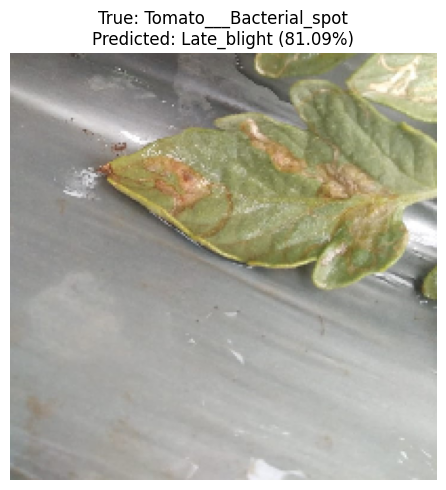

In [21]:
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"True: {true_class}\nPredicted: {pred_class} ({confidence:.2%})",
    fontsize=12
)
plt.tight_layout()
plt.show()


In [22]:
print("=== DETAIL PROBABILITAS ===")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:15s}: {preds[0][i]:.4f}")


=== DETAIL PROBABILITAS ===
Bacterial_spot : 0.0127
Early_blight   : 0.0442
Healthy        : 0.1311
Late_blight    : 0.8109
Leaf_Mold      : 0.0006
Septoria_leaf_spot: 0.0000
Spider_mites   : 0.0000
Target_Spot    : 0.0005
Mosaic_virus   : 0.0000
Yellow_Leaf_Curl: 0.0000


Model Path:
E:\DATASET\MODEL\efficientnetb0_ft10.keras

Model berhasil di-load!

Dataset Asli:
E:\DATASET\Tomato_Resize\train\Tomato___Late_blight\efc16184-1012-4240-934b-85b2396b0d1d___RS_Late.B 5124.JPG

Dataset Eksternal:
E:\DATASET\TomatoDataset\Tomato___Leaf_Mold\IMG-20240727-WA0112.jpg


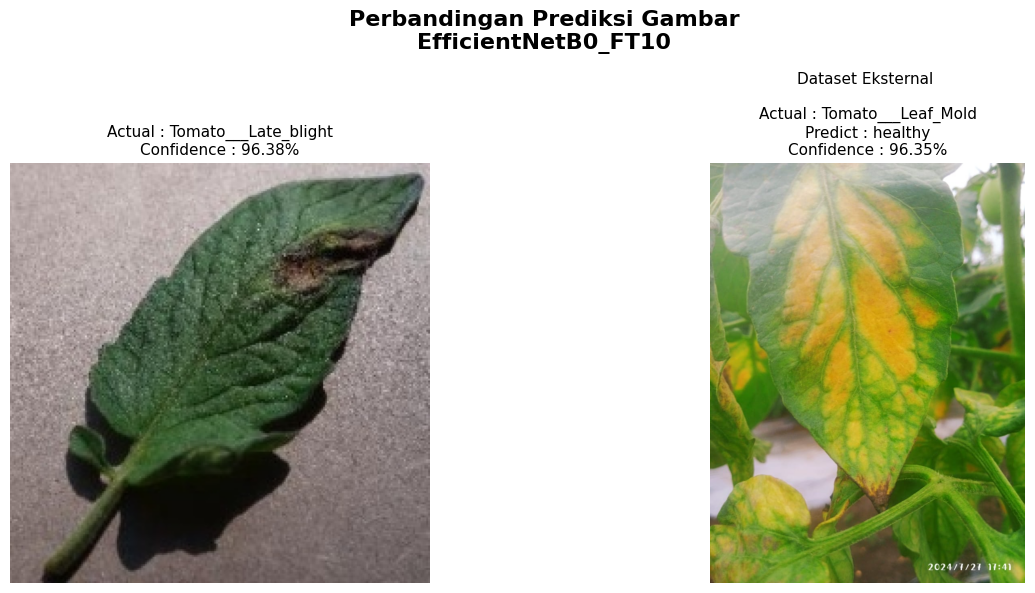

In [23]:
from PIL import Image
# =========================================
# PATH
# =========================================
MODEL_DIR = r"E:\DATASET\MODEL"

ORIGINAL_DIR = r"E:\DATASET\Tomato_Resize"
EXTERNAL_DIR = r"E:\DATASET\TomatoDataset"

# =========================================
# DAFTAR MODEL
# =========================================
model_configs = {

    "MobileNetV2_FE": "mobilenetv2_fe.keras",
    "MobileNetV2_FT10": "mobilenetv2_ft10.keras",
    "MobileNetV2_FT20": "mobilenetv2_ft20.keras",

    "EfficientNetB0_FE": "efficientnetb0_fe.keras",
    "EfficientNetB0_FT10": "efficientnetb0_ft10.keras",
    "EfficientNetB0_FT20": "efficientnetb0_ft20.keras"
}

# =========================================
# PILIH MODEL
# =========================================
model_name = "EfficientNetB0_FT10"

# =========================================
# LOAD MODEL
# =========================================
model_path = os.path.join(
    MODEL_DIR,
    model_configs[model_name]
)

print("Model Path:")
print(model_path)

# cek model
if not os.path.exists(model_path):

    raise FileNotFoundError(
        f"Model tidak ditemukan:\n{model_path}"
    )

model = tf.keras.models.load_model(
    model_path,
    compile=False
)

print("\nModel berhasil di-load!")

# =========================================
# NAMA KELAS
# =========================================
CLASS_NAMES = [
    "Bacterial_spot",
    "Early_blight",
    "healthy",
    "Late_blight",
    "Leaf_Mold",
    "Septoria_leaf_spot",
    "Spider_mites",
    "Target_Spot",
    "Tomato_mosaic_virus",
    "Tomato_Yellow_Leaf_Curl_Virus"
]

# =========================================
# AMBIL RANDOM IMAGE
# =========================================
def get_random_image(data_dir):

    image_files = []

    for root, dirs, files in os.walk(data_dir):

        for f in files:

            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                image_files.append(
                    os.path.join(root, f)
                )

    if len(image_files) == 0:

        raise ValueError(
            f"Tidak ada gambar ditemukan di:\n{data_dir}"
        )

    return np.random.choice(image_files)

# =========================================
# PREDIKSI IMAGE
# =========================================
def predict_image(model, image_path):

    # gambar asli
    original_img = Image.open(image_path).convert("RGB")

    # resize untuk model
    resized_img = original_img.resize((224,224))

    # preprocessing
    img_array = np.array(resized_img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # prediksi
    preds = model.predict(img_array, verbose=0)

    pred_idx = np.argmax(preds)
    confidence = np.max(preds) * 100

    pred_label = CLASS_NAMES[pred_idx]

    return original_img, pred_label, confidence

# =========================================
# AMBIL GAMBAR RANDOM
# =========================================
original_img_path = get_random_image(
    ORIGINAL_DIR
)

external_img_path = get_random_image(
    EXTERNAL_DIR
)

print("\nDataset Asli:")
print(original_img_path)

print("\nDataset Eksternal:")
print(external_img_path)

# =========================================
# PREDIKSI
# =========================================
orig_img, orig_pred, orig_conf = predict_image(
    model,
    original_img_path
)

ext_img, ext_pred, ext_conf = predict_image(
    model,
    external_img_path
)

# =========================================
# LABEL ASLI
# =========================================
orig_actual = os.path.basename(
    os.path.dirname(original_img_path)
)

ext_actual = os.path.basename(
    os.path.dirname(external_img_path)
)

# =========================================
# RESIZE DATASET ASLI -> 224x224
# =========================================
orig_display = orig_img.resize((224,224))

# =========================================
# VISUALISASI
# =========================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

# -----------------------------------------
# DATASET ASLI
# -----------------------------------------
axes[0].imshow(orig_display)

axes[0].set_title(
    f"Actual : {orig_actual}\n"
    f"Confidence : {orig_conf:.2f}%",
    fontsize=11
)

axes[0].axis("off")

# -----------------------------------------
# DATASET EKSTERNAL
# -----------------------------------------
axes[1].imshow(ext_img)

axes[1].set_title(
    f"Dataset Eksternal \n\n"
    f"Actual : {ext_actual}\n"
    f"Predict : {ext_pred}\n"
    f"Confidence : {ext_conf:.2f}%",
    fontsize=11
)

axes[1].axis("off")

# =========================================
# JUDUL
# =========================================
plt.suptitle(
    f"Perbandingan Prediksi Gambar\n{model_name}",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()